In [82]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings as wa
wa.filterwarnings('ignore')

In [83]:
df = pd.read_csv('/content/Airbnb_Open_Data.csv')
df.head(5)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [84]:
df.shape

(102599, 26)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [86]:
null_pre = (df.isnull().sum()/len(df)*100)
null_percentage = null_pre.sort_values(ascending=False)
null_percentage

,0
license,99.998051
house_rules,50.810437
last review,15.490404
reviews per month,15.476759
country,0.518524
availability 365,0.436651
minimum nights,0.398639
host name,0.395715
review rate number,0.317742
calculated host listings count,0.310919


# Drop columns

In [87]:
drop_columns = ['license' , 'house_rules' , 'host name' , 'NAME' , 'last review' , 'id' , 'country code' , 'host id' , 'service fee' , 'country' , 'neighbourhood']

In [88]:
df.drop(columns=drop_columns, inplace=True)
df.head(3)

,host_identity_verified,neighbourhood group,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
0,unconfirmed,Brooklyn,40.64749,-73.97237,False,strict,Private room,2020.0,$966,10.0,9.0,0.21,4.0,6.0,286.0
1,verified,Manhattan,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,$142,30.0,45.0,0.38,4.0,2.0,228.0
2,NaN,Manhattan,40.80902,-73.94190,True,flexible,Private room,2005.0,$620,3.0,0.0,NaN,5.0,1.0,352.0


In [89]:
df.columns

Index(['host_identity_verified', 'neighbourhood group', 'lat', 'long',
       'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'minimum nights', 'number of reviews',
       'reviews per month', 'review rate number',
       'calculated host listings count', 'availability 365'],
      dtype='object')

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   host_identity_verified          102310 non-null  object 
 1   neighbourhood group             102570 non-null  object 
 2   lat                             102591 non-null  float64
 3   long                            102591 non-null  float64
 4   instant_bookable                102494 non-null  object 
 5   cancellation_policy             102523 non-null  object 
 6   room type                       102599 non-null  object 
 7   Construction year               102385 non-null  float64
 8   price                           102352 non-null  object 
 9   minimum nights                  102190 non-null  float64
 10  number of reviews               102416 non-null  float64
 11  reviews per month               86720 non-null   float64
 12  review rate numb

In [91]:
df['reviews per month'].fillna(df['reviews per month'].mean(), inplace=True)

In [92]:
df.isnull().sum()

,0
host_identity_verified,289
neighbourhood group,29
lat,8
long,8
instant_bookable,105
cancellation_policy,76
room type,0
Construction year,214
price,247
minimum nights,409


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   host_identity_verified          102310 non-null  object 
 1   neighbourhood group             102570 non-null  object 
 2   lat                             102591 non-null  float64
 3   long                            102591 non-null  float64
 4   instant_bookable                102494 non-null  object 
 5   cancellation_policy             102523 non-null  object 
 6   room type                       102599 non-null  object 
 7   Construction year               102385 non-null  float64
 8   price                           102352 non-null  object 
 9   minimum nights                  102190 non-null  float64
 10  number of reviews               102416 non-null  float64
 11  reviews per month               102599 non-null  float64
 12  review rate numb

In [94]:
df.dropna(subset=['price'], inplace=True)

In [95]:
float_columns = df.select_dtypes(include=['float64']).columns
float_columns

Index(['lat', 'long', 'Construction year', 'minimum nights',
       'number of reviews', 'reviews per month', 'review rate number',
       'calculated host listings count', 'availability 365'],
      dtype='object')

In [96]:
df.describe()

,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,102344.00000,102344.000000,102142.000000,101943.000000,102169.000000,102352.000000,102026.000000,102033.000000,101904.000000
mean,40.72809,-73.949647,2012.487038,8.125619,27.487878,1.374906,3.279282,7.927200,141.119897
std,0.05587,0.049522,5.765066,30.556607,49.521341,1.606651,1.284458,32.211222,135.425491
min,40.49979,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,40.68873,-73.982570,2007.000000,2.000000,1.000000,0.280000,2.000000,1.000000,3.000000
50%,40.72228,-73.954440,2012.000000,3.000000,7.000000,1.050000,3.000000,1.000000,96.000000
75%,40.76276,-73.932350,2017.000000,5.000000,30.000000,1.710000,4.000000,2.000000,269.000000
max,40.91697,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


In [97]:
df[float_columns] = df[float_columns].fillna(df[float_columns].mean())

In [98]:
str_columns = df.select_dtypes(include=['object']).columns
str_columns

Index(['host_identity_verified', 'neighbourhood group', 'instant_bookable',
       'cancellation_policy', 'room type', 'price'],
      dtype='object')

In [99]:
df[str_columns] = df[str_columns].apply(lambda x:x.fillna(x.mode()[0]))

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102352 entries, 0 to 102598
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   host_identity_verified          102352 non-null  object 
 1   neighbourhood group             102352 non-null  object 
 2   lat                             102352 non-null  float64
 3   long                            102352 non-null  float64
 4   instant_bookable                102352 non-null  bool   
 5   cancellation_policy             102352 non-null  object 
 6   room type                       102352 non-null  object 
 7   Construction year               102352 non-null  float64
 8   price                           102352 non-null  object 
 9   minimum nights                  102352 non-null  float64
 10  number of reviews               102352 non-null  float64
 11  reviews per month               102352 non-null  float64
 12  review rate number   

In [101]:
df.head(5)

,host_identity_verified,neighbourhood group,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
0,unconfirmed,Brooklyn,40.64749,-73.97237,False,strict,Private room,2020.0,$966,10.0,9.0,0.210000,4.0,6.0,286.0
1,verified,Manhattan,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,$142,30.0,45.0,0.380000,4.0,2.0,228.0
2,unconfirmed,Manhattan,40.80902,-73.94190,True,flexible,Private room,2005.0,$620,3.0,0.0,1.374022,5.0,1.0,352.0
3,unconfirmed,Brooklyn,40.68514,-73.95976,True,moderate,Entire home/apt,2005.0,$368,30.0,270.0,4.640000,4.0,1.0,322.0
4,verified,Manhattan,40.79851,-73.94399,False,moderate,Entire home/apt,2009.0,$204,10.0,9.0,0.100000,3.0,1.0,289.0


In [102]:
df['price'] = df['price'].str.replace(',','')
df['price'] = df['price'].str.replace(' ','')
df['price'] = df['price'].str.replace('$','')

In [103]:
df['price'] = df['price'].astype(int)

In [104]:
df.head(5)

,host_identity_verified,neighbourhood group,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
0,unconfirmed,Brooklyn,40.64749,-73.97237,False,strict,Private room,2020.0,966,10.0,9.0,0.210000,4.0,6.0,286.0
1,verified,Manhattan,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,142,30.0,45.0,0.380000,4.0,2.0,228.0
2,unconfirmed,Manhattan,40.80902,-73.94190,True,flexible,Private room,2005.0,620,3.0,0.0,1.374022,5.0,1.0,352.0
3,unconfirmed,Brooklyn,40.68514,-73.95976,True,moderate,Entire home/apt,2005.0,368,30.0,270.0,4.640000,4.0,1.0,322.0
4,verified,Manhattan,40.79851,-73.94399,False,moderate,Entire home/apt,2009.0,204,10.0,9.0,0.100000,3.0,1.0,289.0


In [105]:
df.columns

Index(['host_identity_verified', 'neighbourhood group', 'lat', 'long',
       'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'minimum nights', 'number of reviews',
       'reviews per month', 'review rate number',
       'calculated host listings count', 'availability 365'],
      dtype='object')

In [106]:
df.duplicated().sum()

np.int64(3653)

In [107]:
df.drop_duplicates(subset=df , inplace=True , keep=False)

In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
df.shape

(95145, 15)

In [110]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

In [111]:
def box(val):
    host = df[val]
    plt.figure(figsize=(8,6))
    sns.boxplot(data=df , y=host)
    plt.title(val)
    plt.show()

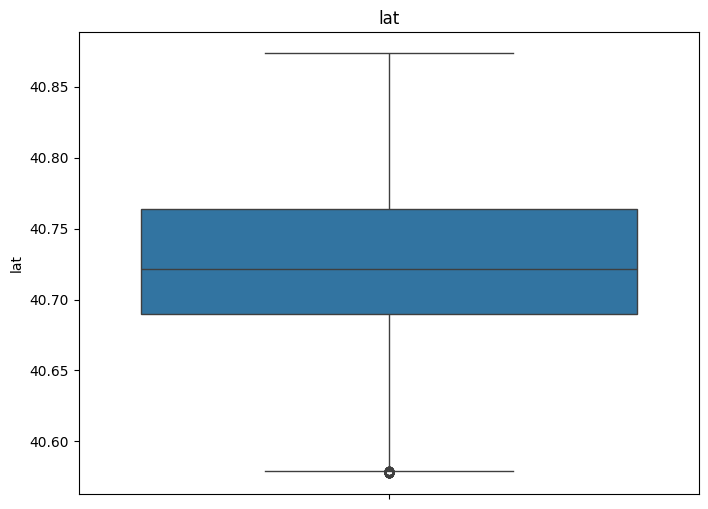

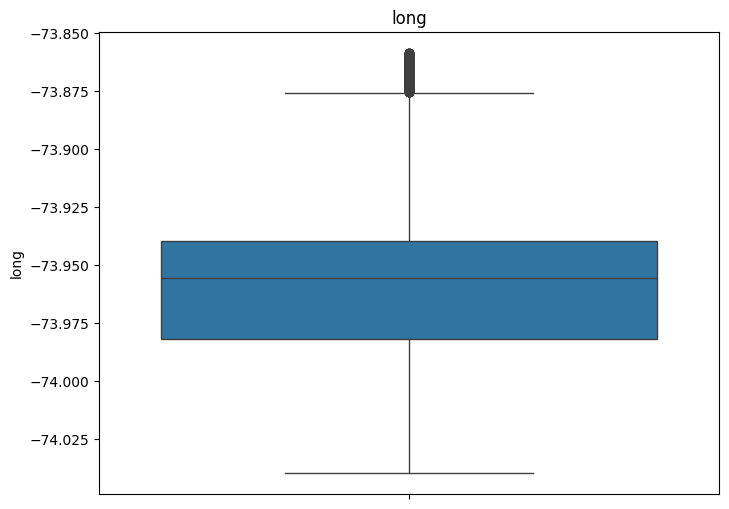

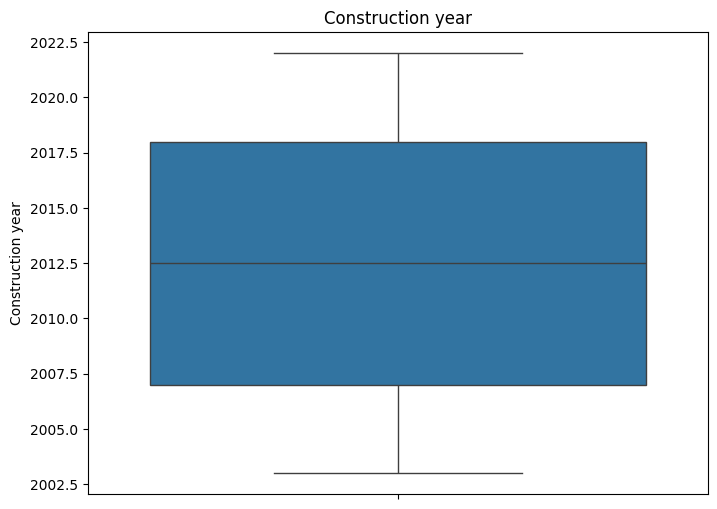

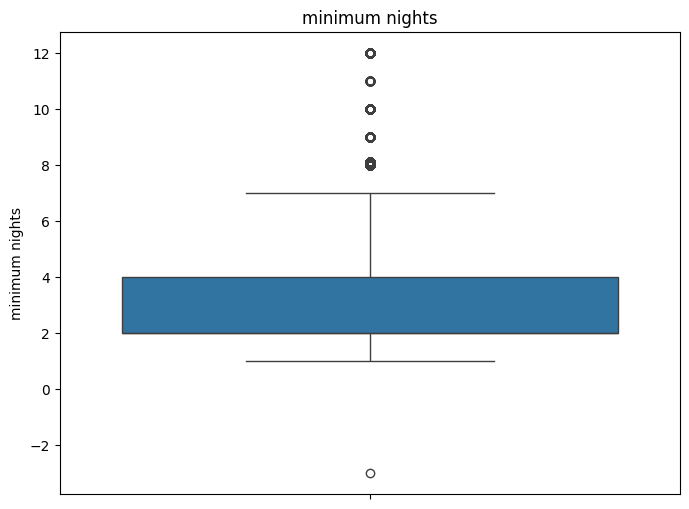

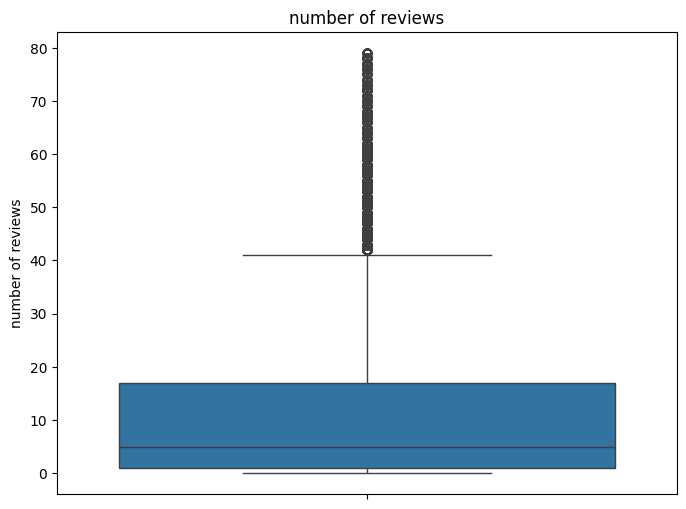

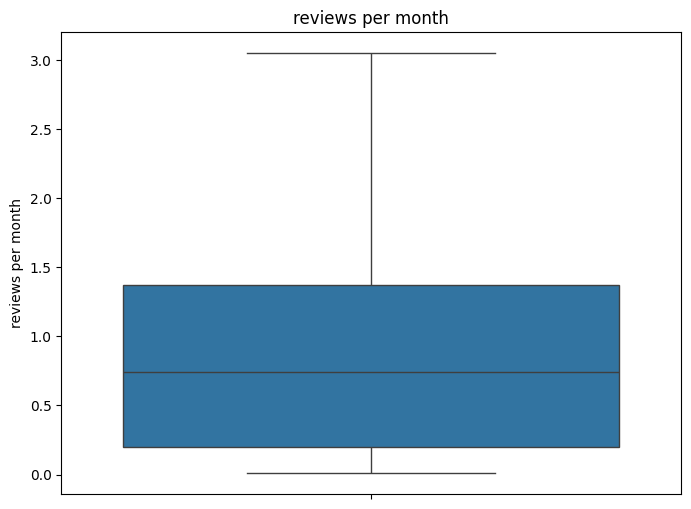

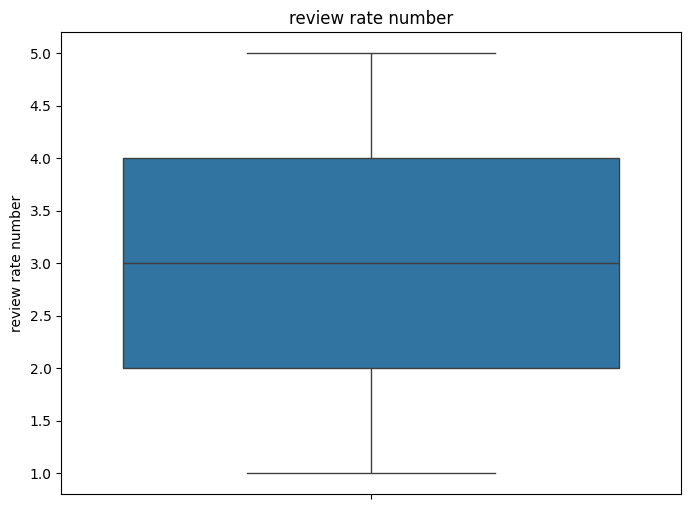

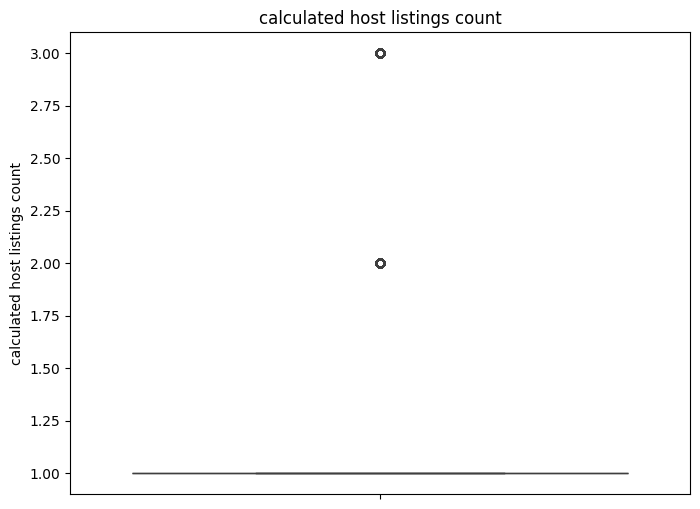

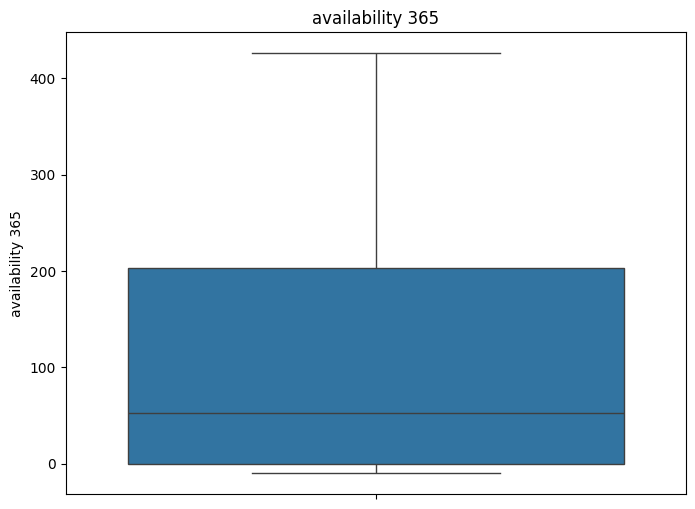

In [112]:
for col in df.select_dtypes(float).columns:
    box(col)

In [113]:
def kde(val):
    host = df[val]
    plt.figure(figsize=(8,6))
    sns.kdeplot(data=df , x=host , fill=True)
    plt.title(val)
    plt.xticks(rotation=90)
    plt.show()

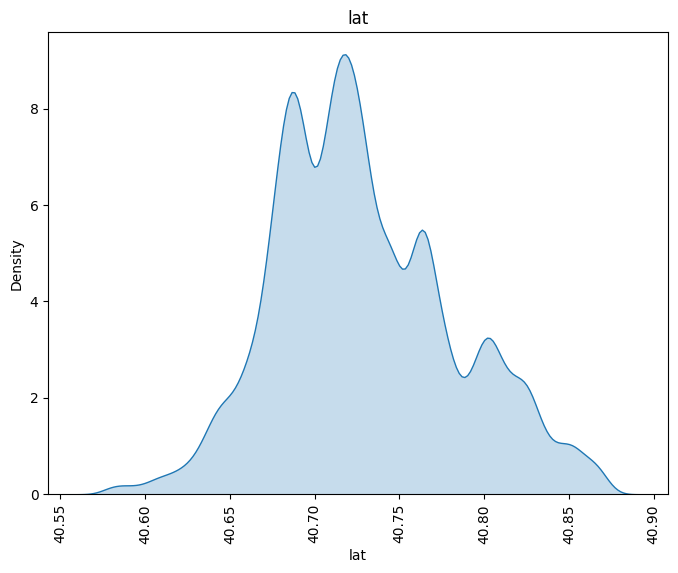

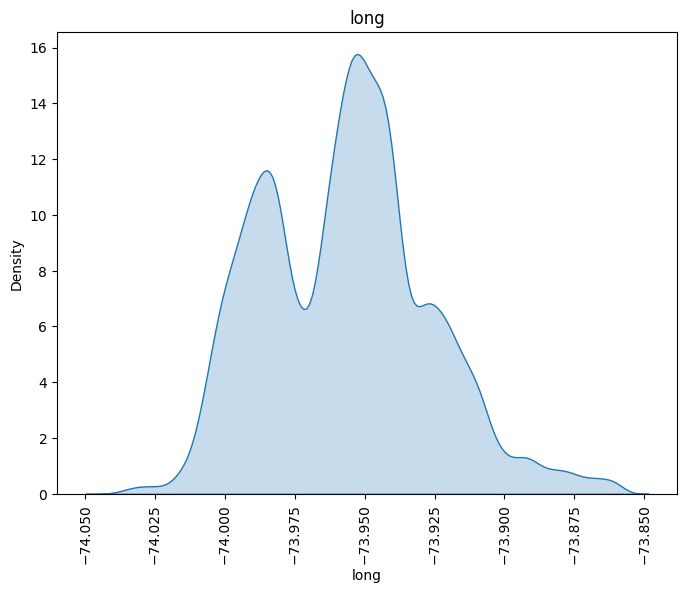

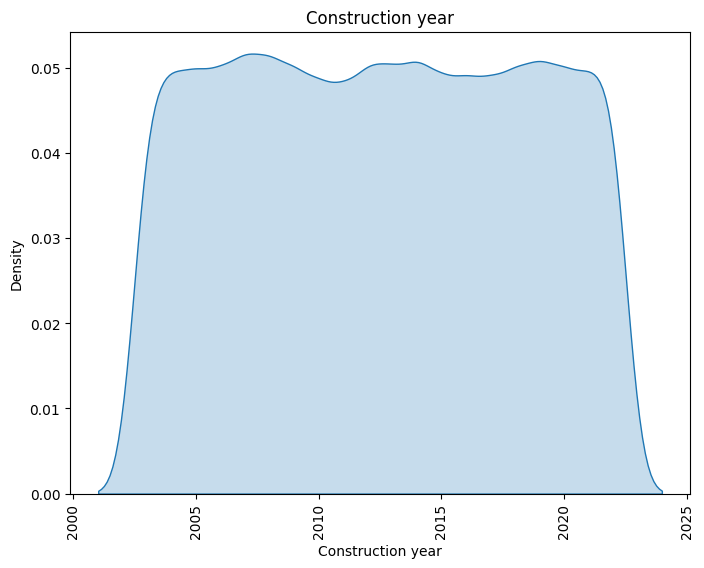

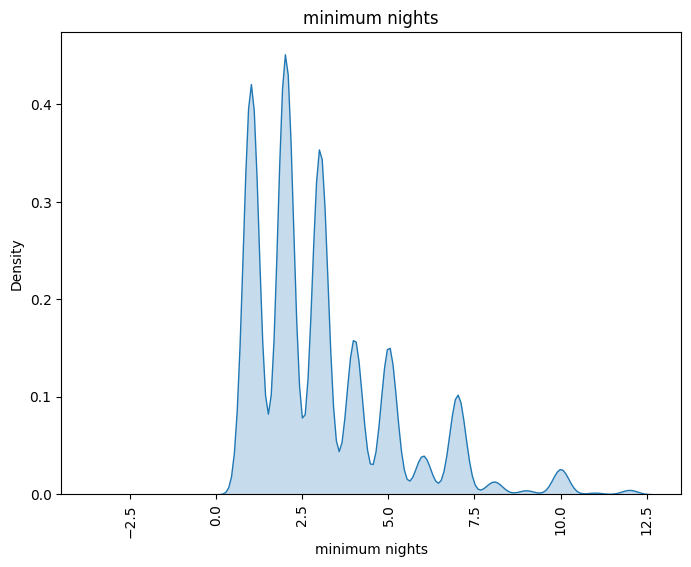

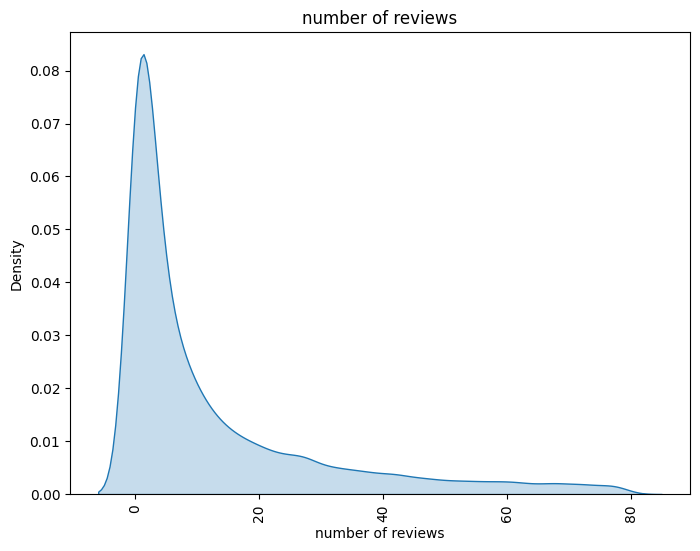

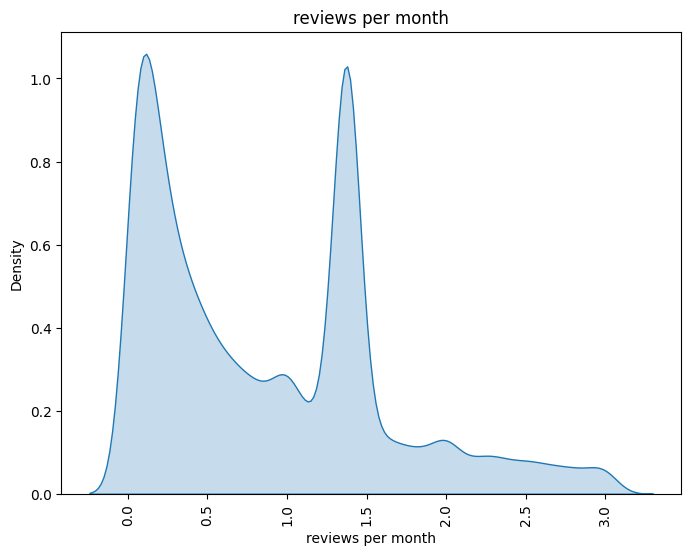

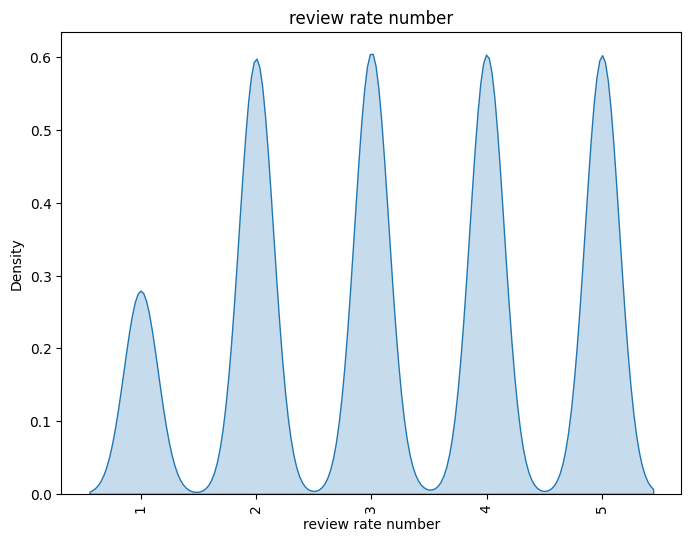

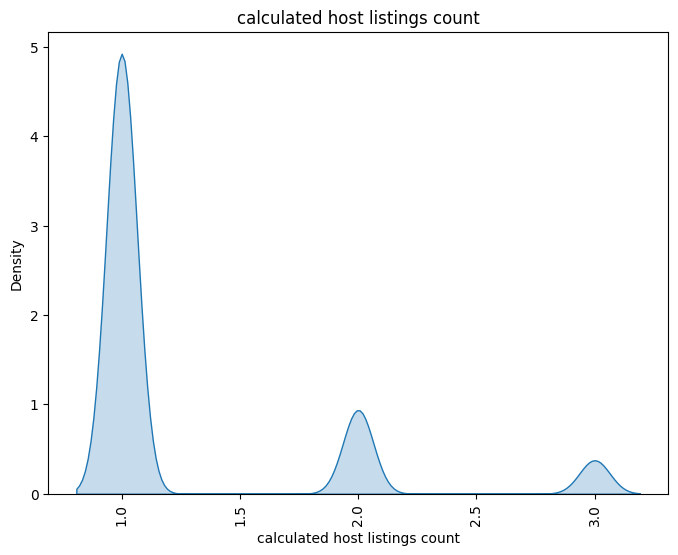

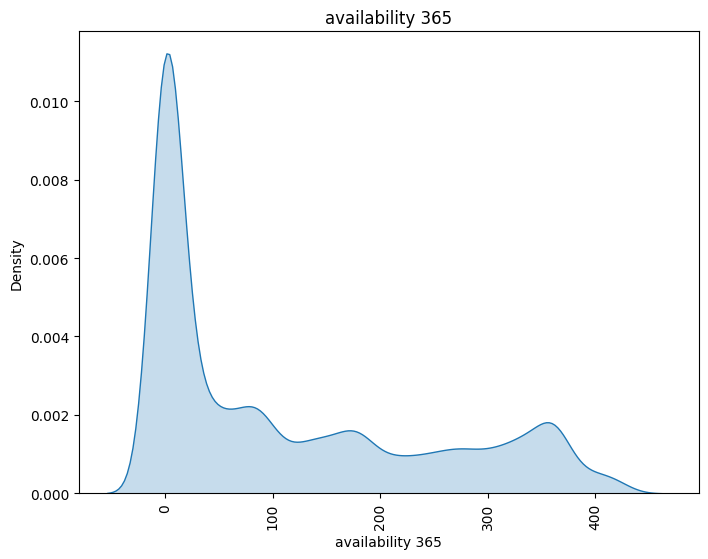

In [114]:
for col in df.select_dtypes(float).columns:
    kde(col)

In [115]:
def scatter(val , com):
    host = df[val]
    cost = df[com]
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df , x=host.head(100) , y=cost.head(100) )
    plt.xticks(rotation=90)
    plt.title(val)
    plt.show()

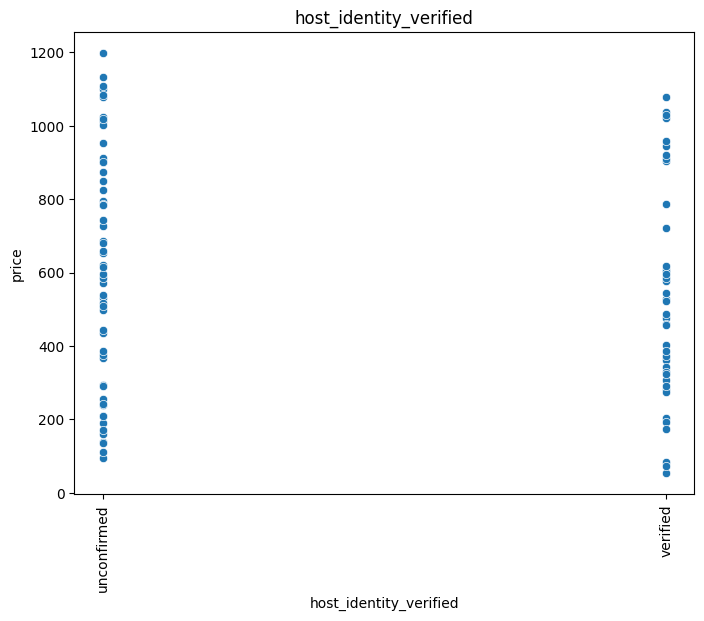

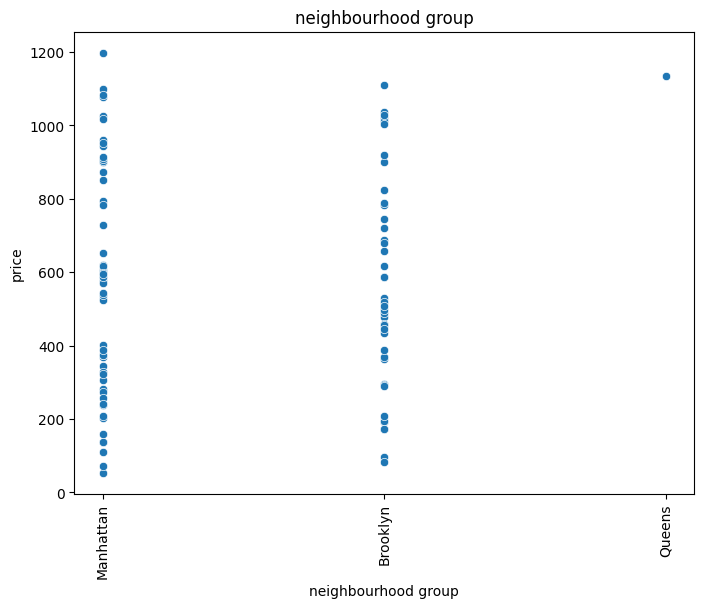

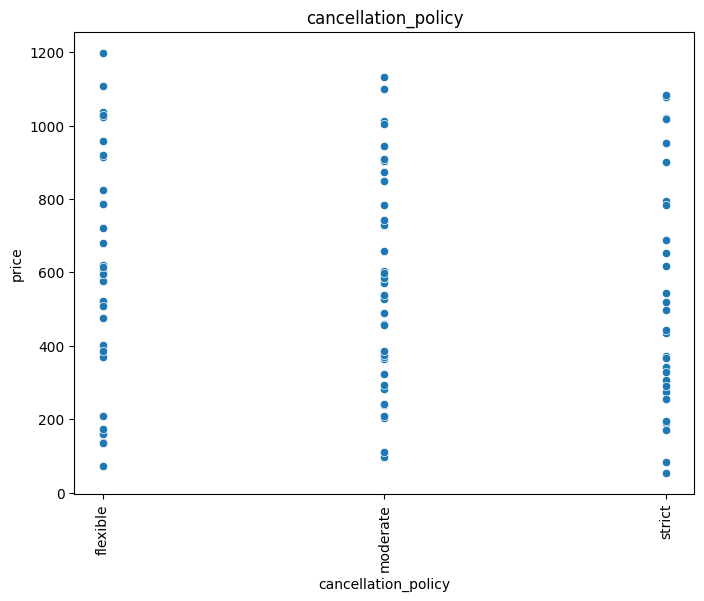

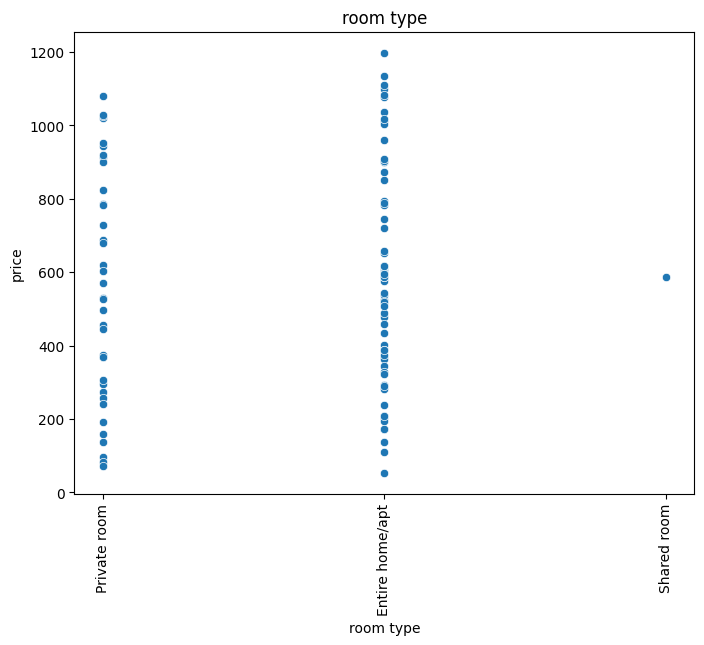

In [116]:
for col in df.select_dtypes(object).columns:
    scatter(col , 'price')

In [117]:
df.shape

(52969, 15)

In [118]:
df.head()

,host_identity_verified,neighbourhood group,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
2,unconfirmed,Manhattan,40.80902,-73.94190,True,flexible,Private room,2005.0,620,3.0,0.0,1.374022,5.0,1.0,352.0
4,verified,Manhattan,40.79851,-73.94399,False,moderate,Entire home/apt,2009.0,204,10.0,9.0,0.100000,3.0,1.0,289.0
5,verified,Manhattan,40.74767,-73.97500,True,flexible,Entire home/apt,2013.0,577,3.0,74.0,0.590000,3.0,1.0,374.0
11,verified,Manhattan,40.80316,-73.96545,True,flexible,Entire home/apt,2008.0,606,5.0,53.0,0.430000,4.0,1.0,163.0
20,verified,Manhattan,40.79685,-73.94872,False,moderate,Entire home/apt,2013.0,281,7.0,0.0,1.374022,3.0,2.0,347.0


In [119]:
from sklearn.preprocessing import OneHotEncoder

In [120]:
X = df.drop(columns='price' , axis=1)
y = df['price']

In [121]:
X.columns

Index(['host_identity_verified', 'neighbourhood group', 'lat', 'long',
       'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'minimum nights', 'number of reviews',
       'reviews per month', 'review rate number',
       'calculated host listings count', 'availability 365'],
      dtype='object')

In [122]:
int_columns = df.select_dtypes(include=['int64' , 'float64']).columns
df[int_columns] = df[int_columns].apply(np.log1p)

# Level encodig

In [123]:
X['instant_bookable'] = X['instant_bookable'].astype(int)

In [124]:
X

,host_identity_verified,neighbourhood group,lat,long,instant_bookable,cancellation_policy,room type,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
2,unconfirmed,Manhattan,40.80902,-73.94190,1,flexible,Private room,2005.000000,3.0,0.0,1.374022,5.0,1.0,352.0
4,verified,Manhattan,40.79851,-73.94399,0,moderate,Entire home/apt,2009.000000,10.0,9.0,0.100000,3.0,1.0,289.0
5,verified,Manhattan,40.74767,-73.97500,1,flexible,Entire home/apt,2013.000000,3.0,74.0,0.590000,3.0,1.0,374.0
11,verified,Manhattan,40.80316,-73.96545,1,flexible,Entire home/apt,2008.000000,5.0,53.0,0.430000,4.0,1.0,163.0
20,verified,Manhattan,40.79685,-73.94872,0,moderate,Entire home/apt,2013.000000,7.0,0.0,1.374022,3.0,2.0,347.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102051,verified,Brooklyn,40.66130,-73.89088,1,moderate,Private room,2012.487038,1.0,0.0,1.374022,4.0,1.0,88.0
102053,unconfirmed,Brooklyn,40.64945,-73.96108,1,moderate,Private room,2012.487038,7.0,12.0,0.440000,5.0,1.0,0.0
102054,verified,Brooklyn,40.69872,-73.92718,0,flexible,Private room,2012.487038,1.0,19.0,0.720000,3.0,2.0,0.0
102056,unconfirmed,Manhattan,40.81248,-73.94317,1,strict,Private room,2012.487038,2.0,0.0,1.374022,1.0,1.0,0.0


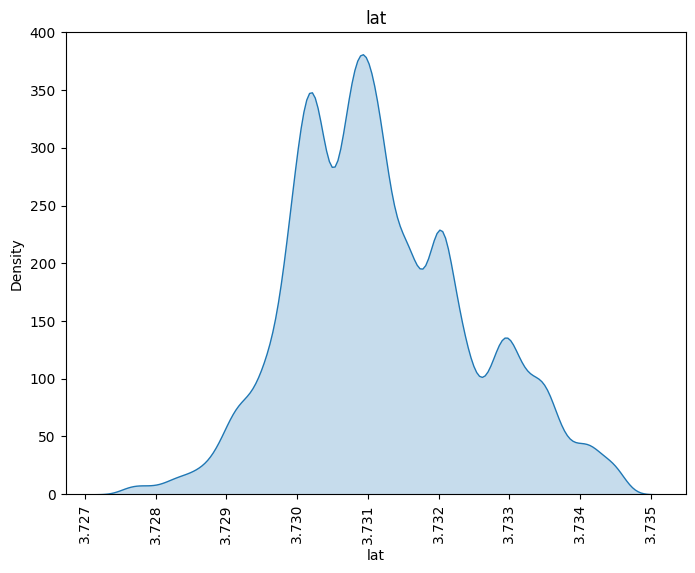

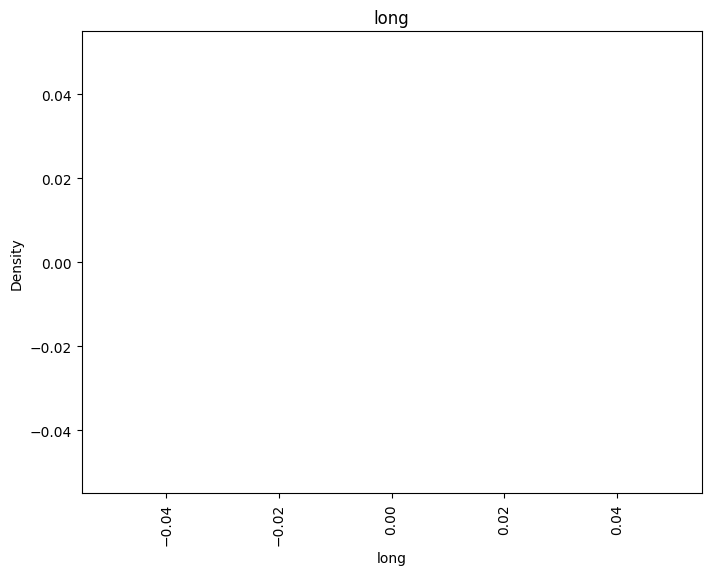

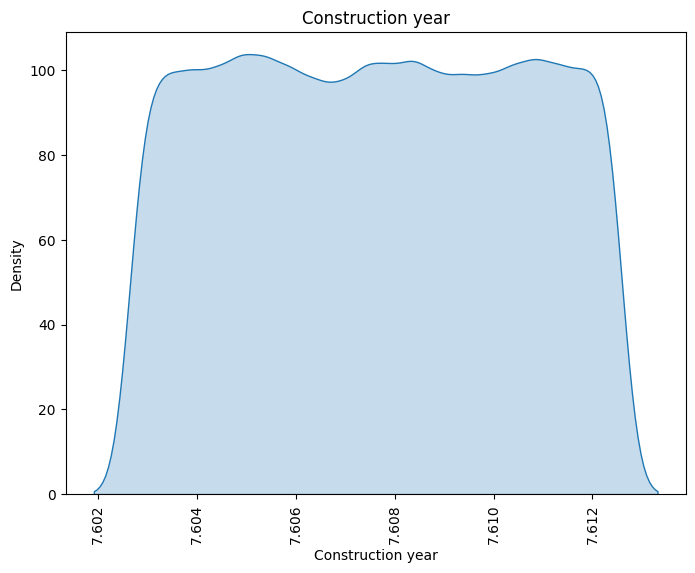

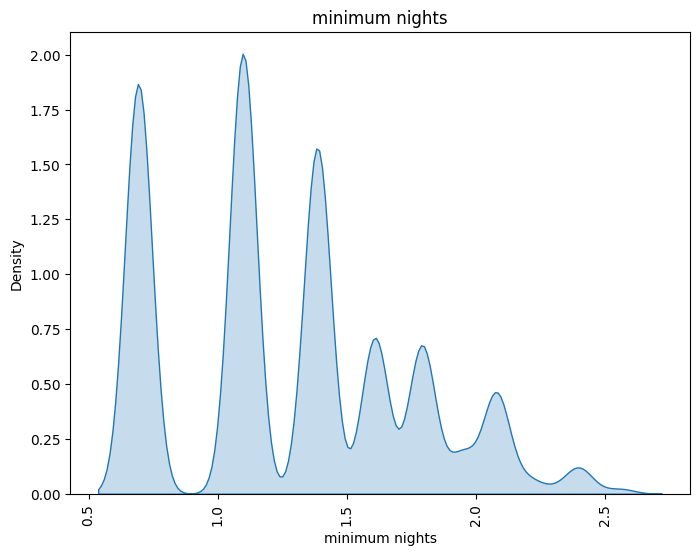

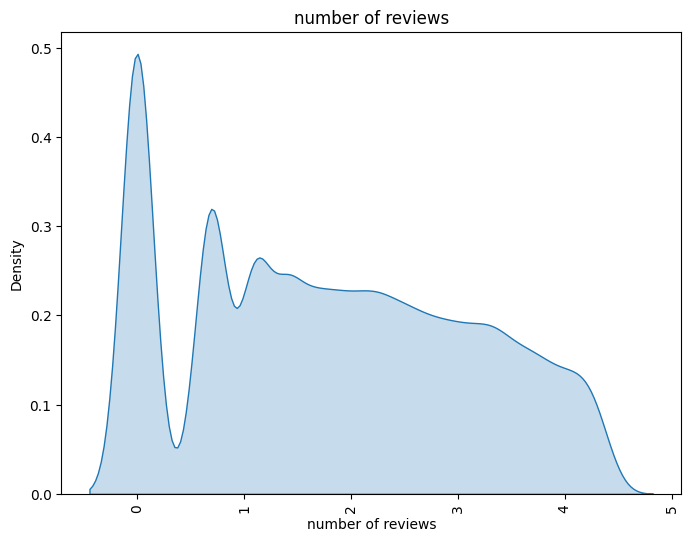

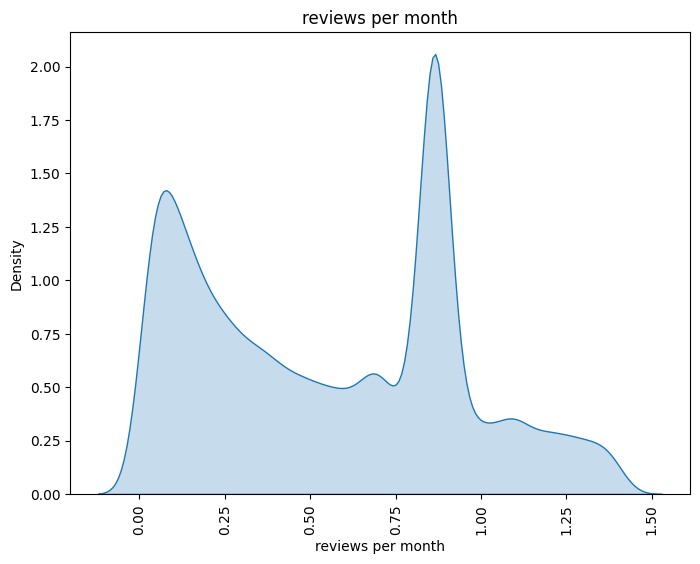

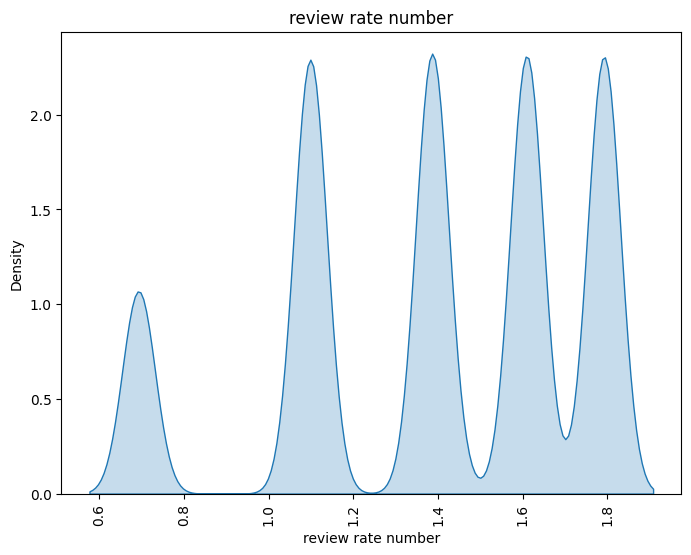

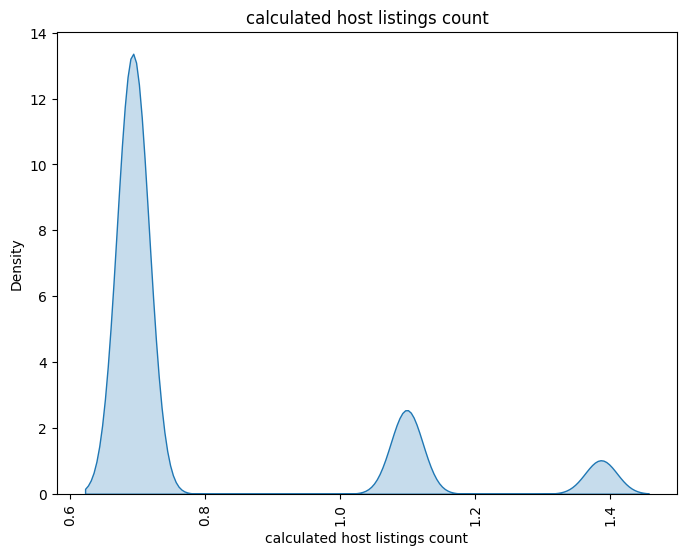

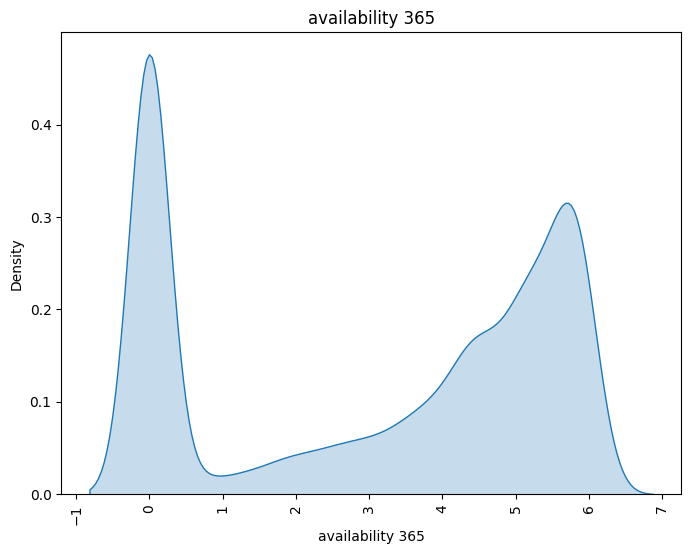

In [125]:
for col in X.select_dtypes(float).columns:
    kde(col)

In [126]:
X.select_dtypes(object).columns

Index(['host_identity_verified', 'neighbourhood group', 'cancellation_policy',
       'room type'],
      dtype='object')

In [127]:
X_encode = pd.get_dummies(data=X, columns=['host_identity_verified', 'neighbourhood group', 'cancellation_policy','room type'] , drop_first=True)

In [128]:
X_encode.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52969 entries, 2 to 102057
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   lat                              52969 non-null  float64
 1   long                             52969 non-null  float64
 2   instant_bookable                 52969 non-null  int64  
 3   Construction year                52969 non-null  float64
 4   minimum nights                   52969 non-null  float64
 5   number of reviews                52969 non-null  float64
 6   reviews per month                52969 non-null  float64
 7   review rate number               52969 non-null  float64
 8   calculated host listings count   52969 non-null  float64
 9   availability 365                 52969 non-null  float64
 10  host_identity_verified_verified  52969 non-null  bool   
 11  neighbourhood group_Brooklyn     52969 non-null  bool   
 12  neighbourhood group_Ma

In [129]:
X_encode.head(5)

,lat,long,instant_bookable,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,host_identity_verified_verified,neighbourhood group_Brooklyn,neighbourhood group_Manhattan,neighbourhood group_Queens,cancellation_policy_moderate,cancellation_policy_strict,room type_Hotel room,room type_Private room,room type_Shared room
2,40.80902,-73.94190,1,2005.0,3.0,0.0,1.374022,5.0,1.0,352.0,False,False,True,False,False,False,False,True,False
4,40.79851,-73.94399,0,2009.0,10.0,9.0,0.100000,3.0,1.0,289.0,True,False,True,False,True,False,False,False,False
5,40.74767,-73.97500,1,2013.0,3.0,74.0,0.590000,3.0,1.0,374.0,True,False,True,False,False,False,False,False,False
11,40.80316,-73.96545,1,2008.0,5.0,53.0,0.430000,4.0,1.0,163.0,True,False,True,False,False,False,False,False,False
20,40.79685,-73.94872,0,2013.0,7.0,0.0,1.374022,3.0,2.0,347.0,True,False,True,False,True,False,False,False,False


In [130]:
X_encode = X_encode.astype(int)
X_encode.head(5)

,lat,long,instant_bookable,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,host_identity_verified_verified,neighbourhood group_Brooklyn,neighbourhood group_Manhattan,neighbourhood group_Queens,cancellation_policy_moderate,cancellation_policy_strict,room type_Hotel room,room type_Private room,room type_Shared room
2,40,-73,1,2005,3,0,1,5,1,352,0,0,1,0,0,0,0,1,0
4,40,-73,0,2009,10,9,0,3,1,289,1,0,1,0,1,0,0,0,0
5,40,-73,1,2013,3,74,0,3,1,374,1,0,1,0,0,0,0,0,0
11,40,-73,1,2008,5,53,0,4,1,163,1,0,1,0,0,0,0,0,0
20,40,-73,0,2013,7,0,1,3,2,347,1,0,1,0,1,0,0,0,0


In [131]:
from sklearn.preprocessing import StandardScaler

In [132]:
X_encode.columns

Index(['lat', 'long', 'instant_bookable', 'Construction year',
       'minimum nights', 'number of reviews', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'host_identity_verified_verified',
       'neighbourhood group_Brooklyn', 'neighbourhood group_Manhattan',
       'neighbourhood group_Queens', 'cancellation_policy_moderate',
       'cancellation_policy_strict', 'room type_Hotel room',
       'room type_Private room', 'room type_Shared room'],
      dtype='object')

In [133]:
scaler = StandardScaler()
X_data = scaler.fit_transform(X_encode)

In [134]:
X_data = pd.DataFrame(X_data , columns=['lat', 'long', 'instant_bookable', 'Construction year',
       'minimum nights', 'number of reviews', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'host_identity_verified_verified',
       'neighbourhood group_Brooklyn', 'neighbourhood group_Manhattan',
       'neighbourhood group_Queens', 'cancellation_policy_moderate',
       'cancellation_policy_strict', 'room type_Hotel room',
       'room type_Private room', 'room type_Shared room'])
X_data

,lat,long,instant_bookable,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,host_identity_verified_verified,neighbourhood group_Brooklyn,neighbourhood group_Manhattan,neighbourhood group_Queens,cancellation_policy_moderate,cancellation_policy_strict,room type_Hotel room,room type_Private room,room type_Shared room
0,0.0,0.260828,1.002249,-1.301042,-0.007004,-0.717432,0.693290,1.349773,-0.480126,1.845061,-0.999377,-0.929405,1.127433,-0.295582,-0.708359,-0.706436,-0.017383,1.090073,-0.131174
1,0.0,0.260828,-0.997756,-0.607648,3.446518,-0.203340,-0.787053,-0.185830,-0.480126,1.361233,1.000623,-0.929405,1.127433,-0.295582,1.411714,-0.706436,-0.017383,-0.917370,-0.131174
2,0.0,0.260828,1.002249,0.085746,-0.007004,3.509550,-0.787053,-0.185830,-0.480126,2.014017,1.000623,-0.929405,1.127433,-0.295582,-0.708359,-0.706436,-0.017383,-0.917370,-0.131174
3,0.0,0.260828,1.002249,-0.780996,0.979716,2.310001,-0.787053,0.581972,-0.480126,0.393575,1.000623,-0.929405,1.127433,-0.295582,-0.708359,-0.706436,-0.017383,-0.917370,-0.131174
4,0.0,0.260828,-0.997756,0.085746,1.966437,-0.717432,0.693290,-0.185830,1.294350,1.806662,1.000623,-0.929405,1.127433,-0.295582,1.411714,-0.706436,-0.017383,-0.917370,-0.131174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52964,0.0,0.260828,1.002249,-0.087602,-0.993725,-0.717432,0.693290,0.581972,-0.480126,-0.182411,1.000623,1.075958,-0.886970,-0.295582,1.411714,-0.706436,-0.017383,1.090073,-0.131174
52965,0.0,0.260828,1.002249,-0.087602,1.966437,-0.031975,-0.787053,1.349773,-0.480126,-0.858235,-0.999377,1.075958,-0.886970,-0.295582,1.411714,-0.706436,-0.017383,1.090073,-0.131174
52966,0.0,0.260828,-0.997756,-0.087602,-0.993725,0.367874,-0.787053,-0.185830,1.294350,-0.858235,1.000623,1.075958,-0.886970,-0.295582,-0.708359,-0.706436,-0.017383,1.090073,-0.131174
52967,0.0,0.260828,1.002249,-0.087602,-0.500364,-0.717432,0.693290,-1.721433,-0.480126,-0.858235,-0.999377,-0.929405,1.127433,-0.295582,-0.708359,1.415556,-0.017383,1.090073,-0.131174


In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , f1_score , classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score

In [136]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size=0.33, random_state=42)

In [137]:
model_lo = KNeighborsClassifier( n_neighbors= 20)
model_lo.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=20)

In [138]:
y_pre = model_lo.predict(X_test)

In [139]:
acc = accuracy_score(y_test, y_pre)
f1 = f1_score(y_test, y_pre, average='weighted')

In [140]:
f1

0.007556558766623624

In [141]:
acc

0.007322654462242563

In [142]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [143]:
from xgboost import XGBRegressor

In [144]:
model_xg = XGBRegressor( subsample= 0.8, n_estimators=500, min_child_weight=3, max_depth= 10, learning_rate= 0.01, gamma= 0, colsample_bytree= 0.6)

In [145]:
model_xg.fit(X_train , y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [146]:
y_pred_xg = model_xg.predict(X_test)

In [148]:
r2 = r2_score(y_test , y_pred_xg)
print(r2)

0.050428569316864014
